<h1 align=center style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazirmatn" color="#0099cc">
تفریحی
</font>
</h1>

<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazirmatn" color="#0099cc">
مقدمه و صورت مسئله
</font>
</h2>

<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazir; font-size:medium">
<font face="vazirmatn" size=3>
    ...
</font>
</p>

<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazirmatn" color="#0099cc">
وارد کردن کتابخانه‌های مورد نیاز
</font>
</h2>

<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazir; font-size:medium">
<font face="vazirmatn" size=3>
    ابتدا کتابخانه‌های مورد نیازتان را وارد کنید.
</font>
</p>

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np 

from sklearn.preprocessing import LabelEncoder

<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazirmatn" color="#0099cc">
معرفی مجموعه داده
</font>
</h2>

<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazir; font-size:medium">
<font face="vazirmatn" size=3>
...    
</font>
</p>

<center>
<div dir=rtl style="direction: rtl;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazirmatn" size=3>
    
|ستون|توضیحات|
|:------:|:---:|
|Created|زمان ثبت بلیط|
|CancelTime|زمانی که مسافر بلیط را کنسل کرده است|
|DepartureTime|زمان حرکت|
|BillID|شناسه خرید|
|TicketID|شناسه بلیط|
|ReserveStatus|تعداد ماشین‌های گذرکرده|
|UserID|شناسه کاربری|
|Male|آیا بلیط متعلق به زن است یا مرد|
|Price|قیمت بلیط بدون تخفیف|
|CouponDiscount|تخفیفی که شخص روی بلیط اعمال کرده است|
|From|مبدا سفر|
|To|مقصد سفر|
|Domestic|آیا سفر، داخلی است یا خارجی|
|VehicleType|جزئیات وسیله نقلیه را مشخص می‌کند|
|VehicleClass|آیا وسیله نقلیه، فرست‌کلس است یا نه|
|Vehicle|نوع وسیله نقلیه|
|Cancel|آیا بلیط کنسل شده‌است یا نه|
|HashPassportNumber_p|هش‌شده شماره پاسپورت|
|HashEmail|هش‌شده ایمیل|
|BuyerMobile|هش‌شده شماره موبایل|
|NationalCode|هش‌شده شماره‌ملی|
|TripReason|دلیل سفر|
    
</font>
</div>
</center>


<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazir; font-size:medium">
<font face="vazirmatn" size=3>
    توضیحات اضافه
</font>
</p>

<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazirmatn" color="#0099cc">
خواندن مجموعه داده
</font>
</h2>

<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazir; font-size:medium">
<font face="vazirmatn" size=3>
    در ابتدا نیاز است فایل‌های مجموعه‌داده را بخوانید. نمونه‌های آموزشی در فایل <code>train.csv</code> و نمونه‌های آزمون که باید دسته‌ی آن‌ها را پیش‌بینی کنید در فایل <code>test.csv</code> ذخیره شده‌اند. اگر لازم دانستید می‌توانید به دلخواه خود بخشی از دادگان آموزشی را به عنوان دادگان اعتبارسنجی نیز جدا کنید.
</font>
</p>

In [2]:
train_data = pd.read_csv('../data/train_data.csv')
train_data

,Created,CancelTime,DepartureTime,BillID,TicketID,ReserveStatus,UserID,Male,Price,CouponDiscount,...,Domestic,VehicleType,VehicleClass,TripReason,Vehicle,Cancel,HashPassportNumber_p,HashEmail,BuyerMobile,NationalCode
0,2022-10-23 09:38:49.110,NaN,2022-11-02 23:59:00,39710203,1091777.0,5,122885.0,True,6600000.0,34425.0,...,1,NaN,False,Work,Plane,0,NaN,66c7f29e3b92f3b77e20830ac29e7758037a53d2238a5b...,764974891906,477368495
1,2022-08-15 14:51:43.160,NaN,2022-08-18 04:15:00,38689463,1070902.0,5,876925.0,True,9500000.0,0.0,...,1,NaN,False,Int,Plane,0,NaN,b24634843858a4175d03422aa9e7211ec3b9f3ce4c481c...,27479149496,15987669
2,2022-09-20 17:25:27.250,NaN,2022-09-21 11:00:00,39245173,7624237.0,3,916640.0,False,2000000.0,0.0,...,1,VIP 2+1,True,Work,Bus,0,NaN,NaN,323657282999,667640412
3,2022-06-25 11:32:53.980,NaN,2022-06-26 08:30:00,37957585,2867547.0,2,NaN,False,40000.0,0.0,...,1,3 ستاره اتوبوسي,NaN,Int,Train,0,NaN,NaN,169459057632,392476186
4,2022-06-01 11:30:53.633,NaN,2022-06-02 23:00:00,37584530,7212559.0,3,NaN,True,1130000.0,0.0,...,1,اسکانیا تک صندلی ۳۱نفره,True,Int,Bus,0,NaN,NaN,408595008421,79497837
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101012,2022-06-01 00:20:14.280,NaN,2022-06-04 12:10:00,37579327,1050781.0,5,NaN,True,5900000.0,0.0,...,1,بوئینگ 737,False,Int,Plane,0,NaN,NaN,605105141718,103215806
101013,2022-10-29 20:54:31.330,NaN,2022-11-01 15:30:00,39789479,3085407.0,2,403095.0,True,926500.0,0.0,...,1,4 ستاره اتوبوسي نگين,NaN,Work,Train,0,NaN,NaN,414997568556,193262890
101014,2022-09-03 17:57:22.067,NaN,2022-09-13 09:30:00,38991563,2322052.0,5,528307.0,True,30000000.0,0.0,...,0,NaN,False,Int,InternationalPlane,0,47b8f2d9b5de7e0e0e7234c18a1aa0c4b35798e6cb46b4...,a4dcb7941ee3c8f7b1fc6a171015692bc961d65a84ad47...,99460830937,34732401
101015,2022-09-29 13:15:51.303,NaN,2022-09-29 17:30:00,39406503,7664730.0,3,797946.0,True,980000.0,0.0,...,1,25 نفره (VIP),True,Work,Bus,0,NaN,718bc52c3e88520531463b385998a1193e2821d518b60b...,487489926847,458338866


In [3]:
test_data = pd.read_csv('../data/test_data.csv')
test_data

,Created,CancelTime,DepartureTime,BillID,TicketID,ReserveStatus,UserID,Male,Price,CouponDiscount,...,To,Domestic,VehicleType,VehicleClass,Vehicle,Cancel,HashPassportNumber_p,HashEmail,BuyerMobile,NationalCode
0,2022-07-22 12:52:35.293,NaN,2022-08-03 17:00:00,38372770,7429183.0,3,NaN,False,1220000.0,0.0,...,اصفهان,1,ماهانVIP مانیتوردار کاوه,True,Bus,0,NaN,7ec2bc45a1a56014c60beb9e6ae72e748563f270b5961e...,855578545022,752371627
1,2022-05-16 10:55:29.397,2022-05-18 11:35:15.643,2022-05-19 17:00:00,37348034,7147402.0,5,NaN,True,2830000.0,0.0,...,قم,1,VIP 2+1 / سیستم تهویه مطبوع / تخت شو,True,Bus,1,NaN,09731a27ab7323fa8a65a5d61a6f6cdf5b127a5d89d1af...,687891042993,926996211
2,2022-02-13 16:10:33.870,NaN,2022-02-15 22:45:00,36058084,6817410.0,3,NaN,True,1480000.0,0.0,...,اردبیل,1,25 نفره (VIP),True,Bus,0,NaN,NaN,515831406373,890191812
3,2022-05-01 17:56:18.530,NaN,2022-05-06 14:30:00,37140430,7093047.0,3,NaN,False,2450000.0,0.0,...,شیراز,1,Scania VIP 2+1,True,Bus,0,NaN,NaN,349742111820,941450742
4,2022-05-19 18:40:48.760,NaN,2022-05-21 12:30:00,37393459,2789874.0,2,135424.0,True,1965500.0,0.0,...,تهران,1,3 ستاره 6 تخته كوير,NaN,Train,0,NaN,a9b7344fa6dffcd85117f3b4209a379600a66019dbfb57...,63387630789,575541645
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43288,2022-10-06 16:57:16.053,NaN,2022-10-07 21:00:00,39515216,7693401.0,3,NaN,True,800000.0,0.0,...,زاهدان,1,classicus 2+2,True,Bus,0,NaN,084471d0e58161bf494c8d540208e17d2b3cb0ea3eff70...,793972140866,560495589
43289,2022-06-14 13:19:26.413,NaN,2022-06-18 07:15:00,37773311,1055789.0,5,NaN,False,7827000.0,0.0,...,تهران,1,NaN,False,Plane,0,NaN,NaN,574095530769,194295556
43290,2022-10-23 15:48:03.947,NaN,2022-10-23 20:25:00,39714891,7747506.0,3,NaN,False,370000.0,0.0,...,قم,1,مارال تک صندلی ۳۰نفره,True,Bus,0,NaN,NaN,82614935547,704290882
43291,2022-09-18 21:18:01.730,2022-09-19 15:40:44.707,2022-09-20 20:00:00,39215621,7620724.0,5,950877.0,True,2520000.0,0.0,...,مسجدسلیمان,1,VIP 2+1 / شارژر یو اس بی / سیستم تهویه مطبوع ...,True,Bus,1,NaN,57f1cffdba91d23d66f923c5defcd40caa8d317f8bcfbc...,242545550300,513968890


<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazirmatn" color="#0099cc">
پیش‌پردازش و مهندسی ویژگی
</font>
</h2>

<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazir; font-size:medium">
<font face="vazirmatn" size=3>
    در این سوال شما می‌توانید از هر تکنیک پیش‌پردازش/مهندسی ویژگی که در فصل‌های گذشته آموختید، استفاده کنید.
    <br>
    تکنیک‌هایی که استفاده می‌کنید به شکل مستقیم مورد ارزیابی توسط سامانه داوری قرار <b>نمی‌گیرند.</b> بلکه همه آن‌ها در دقت مدل شما تاثیر خواهند گذاشت؛ بنابراین هر چه پیش‌پردازش/مهندسی ویژگی بهتری انجام دهید تا دقت مدل بهبود پیدا کند، امتیاز بیشتری از این سوال کسب خواهید کرد.
</font>
</p>

In [4]:

import jdatetime

class Preprocessor  : 
    
    def __init__ (self) : 
    
        self.selected_cols = ['Created', 'DepartureTime', 'BillID', 'TicketID', 'ReserveStatus', \
                'Male', 'Price', 'CouponDiscount', 'From', 'To', 'Domestic',\
                'VehicleClass', 'Vehicle', 'Cancel', 'BuyerMobile', 'TripReason']
        
        self.final_features = ['ReserveStatus',
       'Male', 'Domestic', 'Vehicle', 'Cancel', 'TripReason',
       'TimeDiff', 'TicketPerOrder', 'is_with_familiy', 'net_price',
       'From_encoded', 'To_encoded', 'has_discount']
    
        self.target_col = 'TripReason'


    def to_jalali (self, gregorian_date) : 
        return jdatetime.datetime.fromgregorian(datetime = gregorian_date) 
    
    
    def is_family (self, rows) : 
        return True in rows.values and False in rows.values    

    def select_useful_cols (self, is_train) : 
        if is_train : 
            self.df = self.dataset[self.selected_cols]
        else : 
            test_useful_cols = self.selected_cols.copy()
            test_useful_cols.remove(self.target_col)
            self.df = self.dataset[test_useful_cols]
                        
        
         
    def handle_datetime_cols (self) : 
        self.df[['Created', 'DepartureTime']] = self.df[['Created', 'DepartureTime']].apply(pd.to_datetime)        
        self.df['TimeDiff'] = (self.df['DepartureTime'] - self.df['Created']).dt.days
        self.df.drop(['Created', 'DepartureTime'], axis=1, inplace=True)
            
        
    def extract_ticket_per_order (self) : 
        self.df['TicketPerOrder'] = self.df.groupby('BillID').TicketID.transform('count')
        
    def extract_is_with_family (self) : 
        self.df['is_with_familiy'] = self.df.groupby('BillID').Male.transform(self.is_family)
    
    
    def handle_monetary (self) : 
        self.df['net_price'] = self.df.Price - self.df.CouponDiscount
        self.df['net_price'] /= self.df['net_price'].max()
        self.df['has_discount'] = self.df.CouponDiscount > 0
        
        
    def encode_cities (self, is_train) : 
        if is_train : 
            cities = self.df.From.values
            cities = np.append(cities, self.df.To)
            (self.df.To).values
            self.city_encoder = LabelEncoder().fit(cities)
        try : 
            city2idx = dict(zip(self.city_encoder.classes_, self.city_encoder.transform(self.city_encoder.classes_)))
            
            self.df['From_encoded'] = self.df.From.map(city2idx).fillna(-1).astype(int)
            self.df['To_encoded'] = self.df.To.map(city2idx).fillna(-1).astype(int)
            
            self.df.drop(['To', 'From'], axis=1, inplace=True)
        
        except KeyError as exc:  
            raise Exception('Something went wrong. Maybe this class is used for test date before fit on train data!')
            
            
    def encode_categorical_cols (self, is_train) : 
        if is_train : 
            self.cat_cols = self.df.select_dtypes(exclude=['int','float']).columns
            self.cat_les = {}

            for col in self.cat_cols : 
                le = LabelEncoder().fit(self.df[col])
                self.cat_les.update({col:le})
        
        try : 
            for col in self.cat_cols :
                if col == self.target_col :
                    continue
                self.df[col] = self.cat_les[col].transform(self.df[col])
        except Exception as exc: 
            raise Exception('Something went wrong. Maybe this class is used for test date before fit on train data!')

            
    def select_final_features (self, is_train) : 
        if is_train : 
            self.df = self.df[self.final_features]
        else : 
            test_final_cols = self.final_features.copy()
            test_final_cols.remove(self.target_col)
            self.df = self.df[test_final_cols]
            
        
    
    def transform(self, dataset:pd.DataFrame, is_train=True) : 
        self.dataset = dataset.copy()
        
        self.select_useful_cols(is_train)
        self.handle_datetime_cols()
        self.extract_ticket_per_order()
        self.extract_is_with_family()
        self.handle_monetary()
        self.encode_cities(is_train)
        self.encode_categorical_cols(is_train)
        self.select_final_features(is_train)
        
        return self.df

In [5]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101017 entries, 0 to 101016
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Created               101017 non-null  object 
 1   CancelTime            15326 non-null   object 
 2   DepartureTime         101017 non-null  object 
 3   BillID                101017 non-null  int64  
 4   TicketID              101017 non-null  float64
 5   ReserveStatus         101017 non-null  int64  
 6   UserID                42543 non-null   float64
 7   Male                  101017 non-null  bool   
 8   Price                 101017 non-null  float64
 9   CouponDiscount        101017 non-null  float64
 10  From                  101017 non-null  object 
 11  To                    101017 non-null  object 
 12  Domestic              101017 non-null  int64  
 13  VehicleType           93473 non-null   object 
 14  VehicleClass          62567 non-null   object 
 15  

In [6]:
preprocessor = Preprocessor()
train_df = preprocessor.transform(train_data, is_train = True)

In [7]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101017 entries, 0 to 101016
Data columns (total 13 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   ReserveStatus    101017 non-null  int64  
 1   Male             101017 non-null  int64  
 2   Domestic         101017 non-null  int64  
 3   Vehicle          101017 non-null  int64  
 4   Cancel           101017 non-null  int64  
 5   TripReason       101017 non-null  object 
 6   TimeDiff         101017 non-null  int64  
 7   TicketPerOrder   101017 non-null  int64  
 8   is_with_familiy  101017 non-null  int64  
 9   net_price        101017 non-null  float64
 10  From_encoded     101017 non-null  int64  
 11  To_encoded       101017 non-null  int64  
 12  has_discount     101017 non-null  int64  
dtypes: float64(1), int64(11), object(1)
memory usage: 10.0+ MB


In [8]:
test_df = preprocessor.transform(test_data, is_train=False)

<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazirmatn" color="#0099cc">
مدل‌سازی
</font>
</h2>

<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazir; font-size:medium">
<font face="vazirmatn" size=3>
    حال که داده را پاکسازی کرده و احتمالا ویژگی‌هایی را به آن افزوده یا از آن حذف کرده‌اید، وقت آن است که مدلی آموزش دهید که بتواند متغیر هدف این مسئله را پیش‌بینی کند.
</font>
</p>

In [9]:
Target_map = {'Int' : 0, 'Work' : 1}
train_df['TripReason'] = train_df['TripReason'].map(Target_map)

In [10]:
from sklearn.model_selection import train_test_split

target_col = 'TripReason'

x_train,x_test , y_train,y_test = train_test_split(train_df.drop(target_col,axis=1), train_df[target_col], test_size=.2,\
                                                   random_state=535, stratify=train_df[target_col])

In [11]:
from xgboost import XGBClassifier

model = XGBClassifier()

model.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

<h3 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazirmatn" color="#0099cc">
معیار ارزیابی
</font>
</h3>

<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazir; font-size:medium">
<font face="vazirmatn" size=3>
    معیاری که برای ارزیابی عملکرد مدل انتخاب کرده‌ایم، <code>f1_score</code> نام دارد.
    <br>
    این معیار، سنجه ارزیابی کیفیت مدل شماست. به عبارت بهتر در سامانه داوری هم از همین معیار برای نمره‌دهی استفاده شده است.
    <br>
    پیشنهاد می‌شود با توجه به این معیار، عملکرد مدل خود را بر روی مجموعه داده آموزش یا اعتبارسنجی ارزیابی کنید.
</font>
</p>

              precision    recall  f1-score   support

           0       0.85      0.73      0.78      8914
           1       0.81      0.90      0.85     11290

    accuracy                           0.82     20204
   macro avg       0.83      0.81      0.82     20204
weighted avg       0.82      0.82      0.82     20204



<Axes: >

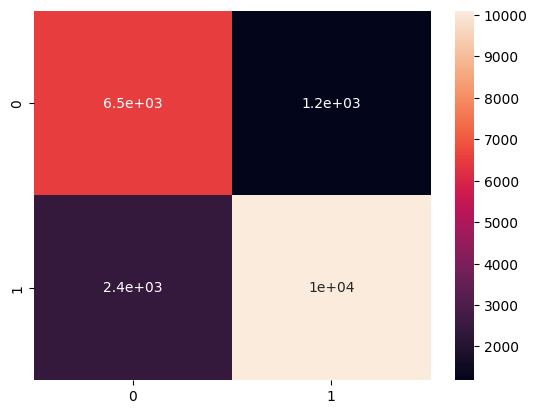

In [12]:
# evaluate model
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(x_test)
print(classification_report(y_test, y_pred))

sns.heatmap(confusion_matrix(y_pred, y_test), annot=True)

<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazir; font-size:medium">
<font color="red"><b color='red'>توجه:</b></font>
<font face="vazirmatn" size=3>
 جهت کسب امتیاز کامل نیاز است تا پاسخ شما حداقل امتیاز <code>75%</code> را با توجه به معیار معرفی‌شده کسب نماید.
</font>
</p>

<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazirmatn" color="#0099cc">
 پیش‌بینی برای داده تست و خروجی
</font>
</h2>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazirmatn" size=3>
    پس از مهندسی ویژگی و مدلسازی، الگوریتمی دارید که می‌تواند شما را از متغیرهای مستقل به متغیر هدف برساند.
    <br>
    از این مدل برای پیش‌بینی نمونه‌های موجود در داده تست استفاده کنید و نتایج را در قالب جدول (<code>dataframe</code>) زیر آماده کنید.
</font>
</p>

<div dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazirmatn" size=3>
    
|ستون|توضیحات|
|------|---|
|TripReason|دلیل سفر|
    
</font>
</div>



<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazirmatn" size=3>
    اسم دیتافریم باید <i>submission</i> باشد؛ در غیر این صورت، سامانه داوری نمی‌تواند تلاش‌ شما را ارزیابی کند.
    <br>
    این دیتافریم تنها شامل ۱ ستون با اسم <i>TripReason</i> است و ۴۳۲۹۳ سطر دارد.
    <br>
    به ازای هر سطر موجود در دیتافریم <i>test</i> شما باید یک مقدار پیشبینی شده داشته باشید.
    <br>
    جدول زیر، ۵ سطر ابتدایی دیتافریم <code>submission</code> را نشان می‌دهد. البته در جواب شما، مقادیر ستون <i>TripReason</i> ممکن است متفاوت باشد.
</font>
</p>

<div style="text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazirmatn" size=3>
    
||target_5yrs|
|----|-----|
|0|Work|
|1|Work|
|2|Int|
|3|Int|
|4|Work|

</font>
</div>



In [13]:
# Reverse the mapping
reverse_target_map = {v: k for k, v in Target_map.items()}

# predict test samples
submission = model.predict(test_df)
submission = pd.DataFrame(submission, columns=['TripReason'])
submission['TripReason'] = submission['TripReason'].map(reverse_target_map)
submission

,TripReason
0,Work
1,Int
2,Work
3,Work
4,Work
...,...
43288,Work
43289,Int
43290,Work
43291,Work


<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazirmatn" color="#0099cc">
<b>سلول جواب‌ساز</b>
</font>
</h2>

<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazir; font-size:medium">
<font face="vazirmatn" size=3>
    برای ساخته‌شدن فایل <code>result.zip</code> سلول زیر را اجرا کنید. توجه داشته باشید که پیش از اجرای سلول زیر تغییرات اعمال شده در نت‌بوک را ذخیره کرده باشید (<code>ctrl+s</code>) تا در صورت نیاز به پشتیبانی امکان بررسی کد شما وجود داشته باشد.
</font>
</p>

In [15]:
import zipfile
import joblib

def compress(file_names):
    print("File Paths:")
    print(file_names)
    compression = zipfile.ZIP_DEFLATED
    with zipfile.ZipFile("result.zip", mode="w") as zf:
        for file_name in file_names:
            zf.write('./' + file_name, file_name, compress_type=compression)

joblib.dump(model, 'model')
submission.to_csv('submission.csv', index=False)
file_names = ['tafrihi.ipynb', 'submission.csv', 'model']
compress(file_names)

File Paths:
['tafrihi.ipynb', 'submission.csv', 'model']


<h4 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazirmatn" color="#0099cc">
<b>راهنمایی</b>
</font>
</h4>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazirmatn" size=3>
    ...
</font>
</p>